# 1. Import Libraries

In [40]:
!pip install transformers torch nltk


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


# 2. Import Pipeline

In [41]:
from transformers import pipeline

pretrained_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

classifier = pipeline(
    "sentiment-analysis",
    model=pretrained_name,
    tokenizer=pretrained_name,
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6970.74it/s]


# 3. Try Model

In [42]:
text = "Ekonomi Indonesia sedang tumbuh dengan baik"
print(classifier(text))

text = "Ekonomi Indonesia sedang tumbuh dengan jelek"
print(classifier(text))

[{'label': 'positive', 'score': 0.9899829626083374}]
[{'label': 'negative', 'score': 0.9991164803504944}]


# 4. Import Data

In [43]:
import pandas as pd

df = pd.read_csv("./dataset.csv")
df

,No,URL,Judul,Konten,Sentiment
0,1,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive
1,2,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive
2,3,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive
3,4,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative
4,5,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive
...,...,...,...,...,...
195,196,https://www.cnbcindonesia.com/news/20250307062...,Senjata Makan Tuan! Perang Dagang 'Tusuk' AS-T...,"Jakarta, CNBC Indonesia- Presiden Amerika Seri...",NaN
196,197,https://www.voaindonesia.com/a/mark-carney-aka...,Mark Carney akan Jadi Perdana Menteri Baru Kan...,"Lihat komentar\nCarney, seorang pemula dalam k...",NaN
197,198,https://www.tempo.co/internasional/gara-gara-t...,"Gara-gara Tarif Impor, Cina Tantang Perang AS ...","TEMPO.CO,Jakarta-Cinamenyatakan siap untuk ber...",NaN
198,199,https://www.metrotvnews.com/read/KXyCQ62j-saha...,Saham AS Mulai Bangkit di Tengah Celah Konsesi...,New York: Saham-saham Amerika Serikat (AS) diW...,NaN


# 5. Text Preprocessing (Bahasa Indonesia)

In [44]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Initialize Sastrawi tools
stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stopword_factory.get_stop_words())
USE_STEMMING = False

# Add custom stopwords if needed (common filler words in articles)
custom_stopwords = {
    'yang', 'dan', 'di', 'dari', 'untuk', 'pada', 'dengan',
    'ini', 'itu', 'ke', 'dalam', 'adalah', 'juga', 'tidak',
    'akan', 'ada', 'atau', 'bisa', 'sudah', 'lebih', 'oleh',
    'hal', 'saat', 'dapat', 'telah', 'mereka', 'saya', 'kami',
    'kita', 'hanya', 'seperti', 'tentang', 'antara', 'lain',
    'maka', 'jika', 'bagi', 'pun', 'lagi', 'masih', 'ia',
    'dia', 'anda', 'kata', 'ujar', 'ucap', 'tutur', 'sebut'
}
all_stopwords = indonesian_stopwords.union(custom_stopwords)

if USE_STEMMING:
    stemmer_factory = StemmerFactory()
    stemmer = stemmer_factory.createStemmer()
    print("Stemmer initialized (this may take a moment).")

print(f"Total stopwords loaded: {len(all_stopwords)}")

Total stopwords loaded: 129


In [45]:
import regex as re
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

def preprocess_text(text):
    """
    Full preprocessing pipeline for Bahasa Indonesia text.

    Steps:
    1. Lowercase
    2. Remove URLs
    3. Remove HTML tags
    4. Remove numbers
    5. Remove punctuation and special characters
    6. Tokenize
    7. Remove stopwords
    8. Remove short tokens (length < 3)
    9. (Optional) Stemming

    Args:
        text (str): Raw article text

    Returns:
        list: List of cleaned tokens
    """
    if not isinstance(text, str):
        return []

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # Step 3: Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Step 4: Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Step 5: Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', ' ', text)

    # Step 6: Tokenize
    tokens = word_tokenize(text)

    return tokens

In [46]:
print("Preprocessing articles...")
df["tokens_preprocessed"] = df["Konten"].apply(preprocess_text)
df["text_preprocessed"] = df["tokens_preprocessed"].apply(lambda x: " ".join(x))
df

Preprocessing articles...


,No,URL,Judul,Konten,Sentiment,tokens_preprocessed,text_preprocessed
0,1,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,"[jakarta, cnbc, indonesia, amerika, serikat, a...",jakarta cnbc indonesia amerika serikat as seca...
1,2,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,"[jakarta, cnbc, indonesia, nilai, tukar, rupia...",jakarta cnbc indonesia nilai tukar rupiah terh...
2,3,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,"[jakarta, cnbc, indonesia, pasar, keuangan, in...",jakarta cnbc indonesia pasar keuangan indonesi...
3,4,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,"[jakarta, cnbc, indonesia, indeks, harga, saha...",jakarta cnbc indonesia indeks harga saham gabu...
4,5,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,"[hargabitcoin, btc, pernah, melewati, angka, t...",hargabitcoin btc pernah melewati angka terting...
...,...,...,...,...,...,...,...
195,196,https://www.cnbcindonesia.com/news/20250307062...,Senjata Makan Tuan! Perang Dagang 'Tusuk' AS-T...,"Jakarta, CNBC Indonesia- Presiden Amerika Seri...",NaN,"[jakarta, cnbc, indonesia, presiden, amerika, ...",jakarta cnbc indonesia presiden amerika serika...
196,197,https://www.voaindonesia.com/a/mark-carney-aka...,Mark Carney akan Jadi Perdana Menteri Baru Kan...,"Lihat komentar\nCarney, seorang pemula dalam k...",NaN,"[lihat, komentar, carney, seorang, pemula, dal...",lihat komentar carney seorang pemula dalam kan...
197,198,https://www.tempo.co/internasional/gara-gara-t...,"Gara-gara Tarif Impor, Cina Tantang Perang AS ...","TEMPO.CO,Jakarta-Cinamenyatakan siap untuk ber...",NaN,"[tempo, co, jakarta, cinamenyatakan, siap, unt...",tempo co jakarta cinamenyatakan siap untuk ber...
198,199,https://www.metrotvnews.com/read/KXyCQ62j-saha...,Saham AS Mulai Bangkit di Tengah Celah Konsesi...,New York: Saham-saham Amerika Serikat (AS) diW...,NaN,"[new, york, saham, saham, amerika, serikat, as...",new york saham saham amerika serikat as diwall...


# 6. Perform Sentiment Analysis

In [47]:
df["sentiment_bert"] = df["text_preprocessed"].apply(lambda x: classifier(x[:256])[0])

df["label_bert"] = df["sentiment_bert"].apply(lambda x: x["label"])
df["score_bert"] = df["sentiment_bert"].apply(lambda x: x["score"])

In [48]:
df

,No,URL,Judul,Konten,Sentiment,tokens_preprocessed,text_preprocessed,sentiment_bert,label_bert,score_bert
0,1,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,"[jakarta, cnbc, indonesia, amerika, serikat, a...",jakarta cnbc indonesia amerika serikat as seca...,"{'label': 'neutral', 'score': 0.9938921928405762}",neutral,0.993892
1,2,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,"[jakarta, cnbc, indonesia, nilai, tukar, rupia...",jakarta cnbc indonesia nilai tukar rupiah terh...,"{'label': 'neutral', 'score': 0.9967818260192871}",neutral,0.996782
2,3,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,"[jakarta, cnbc, indonesia, pasar, keuangan, in...",jakarta cnbc indonesia pasar keuangan indonesi...,"{'label': 'neutral', 'score': 0.9963729381561279}",neutral,0.996373
3,4,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,"[jakarta, cnbc, indonesia, indeks, harga, saha...",jakarta cnbc indonesia indeks harga saham gabu...,"{'label': 'neutral', 'score': 0.9941734671592712}",neutral,0.994173
4,5,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,"[hargabitcoin, btc, pernah, melewati, angka, t...",hargabitcoin btc pernah melewati angka terting...,"{'label': 'neutral', 'score': 0.9477119445800781}",neutral,0.947712
...,...,...,...,...,...,...,...,...,...,...
195,196,https://www.cnbcindonesia.com/news/20250307062...,Senjata Makan Tuan! Perang Dagang 'Tusuk' AS-T...,"Jakarta, CNBC Indonesia- Presiden Amerika Seri...",NaN,"[jakarta, cnbc, indonesia, presiden, amerika, ...",jakarta cnbc indonesia presiden amerika serika...,"{'label': 'neutral', 'score': 0.995879054069519}",neutral,0.995879
196,197,https://www.voaindonesia.com/a/mark-carney-aka...,Mark Carney akan Jadi Perdana Menteri Baru Kan...,"Lihat komentar\nCarney, seorang pemula dalam k...",NaN,"[lihat, komentar, carney, seorang, pemula, dal...",lihat komentar carney seorang pemula dalam kan...,"{'label': 'neutral', 'score': 0.9908801317214966}",neutral,0.990880
197,198,https://www.tempo.co/internasional/gara-gara-t...,"Gara-gara Tarif Impor, Cina Tantang Perang AS ...","TEMPO.CO,Jakarta-Cinamenyatakan siap untuk ber...",NaN,"[tempo, co, jakarta, cinamenyatakan, siap, unt...",tempo co jakarta cinamenyatakan siap untuk ber...,"{'label': 'neutral', 'score': 0.9968162178993225}",neutral,0.996816
198,199,https://www.metrotvnews.com/read/KXyCQ62j-saha...,Saham AS Mulai Bangkit di Tengah Celah Konsesi...,New York: Saham-saham Amerika Serikat (AS) diW...,NaN,"[new, york, saham, saham, amerika, serikat, as...",new york saham saham amerika serikat as diwall...,"{'label': 'neutral', 'score': 0.9978280663490295}",neutral,0.997828


# 7. Analyse Results

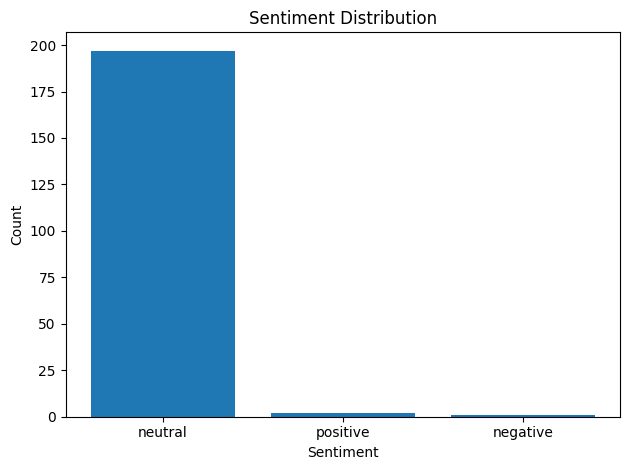

In [49]:
import matplotlib.pyplot as plt

counts = df["label_bert"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.tight_layout()
plt.show()